# Cài đặt các Thư viện sử dụng

In [73]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import joblib
from underthesea import word_tokenize
import os

In [74]:
import warnings
warnings.filterwarnings("ignore")

# Cài đặt hiển thị dataFrame

In [75]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Đọc dữ liệu


- vn_news_223_tdlfr.csv là file chứa news cần xử lý
- vietnamese-stopwords.txt chứa các stop word cần xử lý

In [76]:
file = os.path.join("../../Data_Train", "English.csv")
data_df = pd.read_csv(file, encoding = 'utf-8')

# Khám phá dữ liệu

## Mẫu dữ liệu

In [77]:
data_df.sample(1)

title  \
8496  Trump s remarks on gun rights Clinton unleash torrent of criticism   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

## Xem thông tin

In [78]:
data_df["title_length"] = data_df["title"].apply(lambda title: len(title.split(" ")))
data_df["text_length"] = data_df["text"].apply(lambda text: len(text.split(" ")))

In [79]:
data_df[["title_length", "text_length"]].describe()

,title_length,text_length
count,39000.000000,39000.000000
mean,12.573256,405.981795
std,4.075220,283.286978
min,1.000000,19.000000
25%,10.000000,230.000000
50%,12.000000,372.000000
75%,14.000000,516.000000
max,42.000000,7033.000000


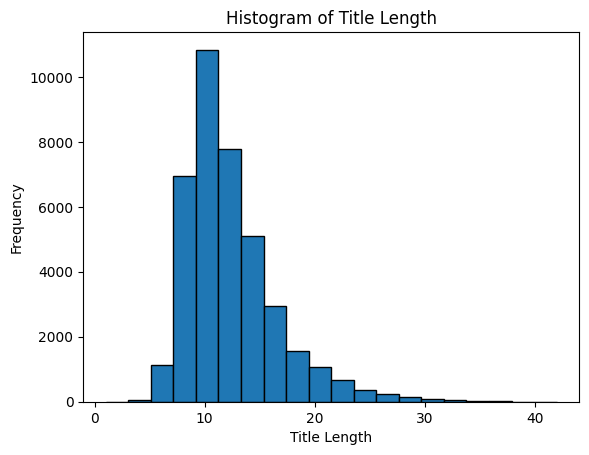

In [80]:
data_df["title_length"].plot(kind="hist", bins=20, edgecolor='black')
plt.title('Histogram of Title Length')
plt.xlabel('Title Length')
plt.ylabel('Frequency')
plt.show()

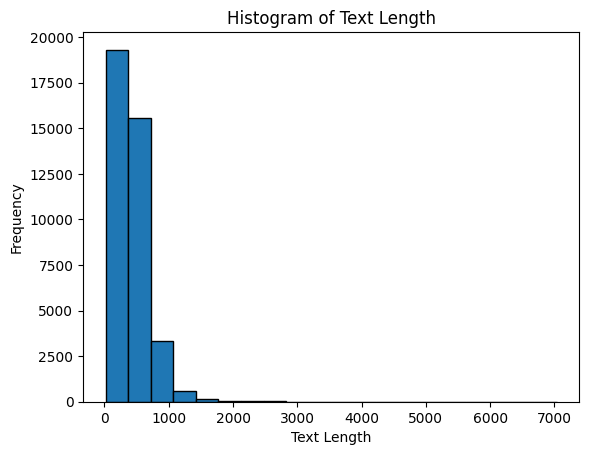

In [81]:
data_df["text_length"].plot(kind="hist", bins=20, edgecolor='black')
plt.title('Histogram of Text Length')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.show()

In [82]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39000 entries, 0 to 38999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   title         39000 non-null  object
 1   text          39000 non-null  object
 2   label         39000 non-null  int64 
 3   title_length  39000 non-null  int64 
 4   text_length   39000 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 1.5+ MB


## Xem mô tả

In [83]:
data_df.describe().round(1)

,label,title_length,text_length
count,39000.0,39000.0,39000.0
mean,0.5,12.6,406.0
std,0.5,4.1,283.3
min,0.0,1.0,19.0
25%,0.0,10.0,230.0
50%,0.5,12.0,372.0
75%,1.0,14.0,516.0
max,1.0,42.0,7033.0


## Xem số dòng và số cột của dữ liệu

In [84]:
num_rows=data_df.shape[0]
num_cols=data_df.shape[1]
print(num_rows)
print(num_cols)

39000
5


## ý nghĩa của các dòng

### Kiểm tra dữ liệu có bị lặp ?

In [85]:
dup=data_df.index.duplicated().sum()
dup

0

### ý nghĩa các cột

- text: nội dung của tin tức
- domain: đường dẫn đến trang web chứa tin tức 
- label: nhãn phân biệt tin giả hay tin thật

### Dữ liệu có bị thiếu không?

In [86]:
data_df['title'].isnull().sum()

0

In [87]:
data_df['text'].isnull().sum()

0

In [88]:
data_df['label'].isnull().sum()

0

### Mỗi cột hiện đang có kiểu dữ liệu gì? Có cột nào có kiểu dữ liệu chưa phù hợp để có thể xử lý tiếp không?

In [89]:
data_df.dtypes

title           object
text            object
label            int64
title_length     int64
text_length      int64
dtype: object

#### Cột có dtype là object nghĩa là sao?

- Trong Pandas, kiểu dữ liệu object thường ám chỉ chuỗi, nhưng thật ra kiểu dữ liệu object có thể chứa một đối tượng bất kỳ trong Python (vì thật ra ở bên dưới kiểu dữ liệu object chứa địa chỉ).
- Nếu một cột trong dataframe có dtype là object thì có thể các phần tử trong cột này sẽ có kiểu dữ liệu khác nhau
- Để biết được kiểu dữ liệu thật sự của các phần tử trong cột này thì ta phải truy xuất vào từng phần tử. Ta muốn xem thử trong nội bộ mỗi cột này có các kiểu dữ liệu nào

In [90]:
def open_object_dtype(s):
    dtypes = set()
    s=s.apply(type)
    dtypes.update(s.unique().tolist())
    return dtypes

In [91]:
open_object_dtype(data_df['title'])

{str}

In [92]:
open_object_dtype(data_df['text'])

{str}

In [93]:
open_object_dtype(data_df['label'])

{int}

In [94]:
data_df.isnull().sum()

title           0
text            0
label           0
title_length    0
text_length     0
dtype: int64

#### Kiểm tra phân bố các class có chênh lệch không?

Xem phân bố dữ liệu

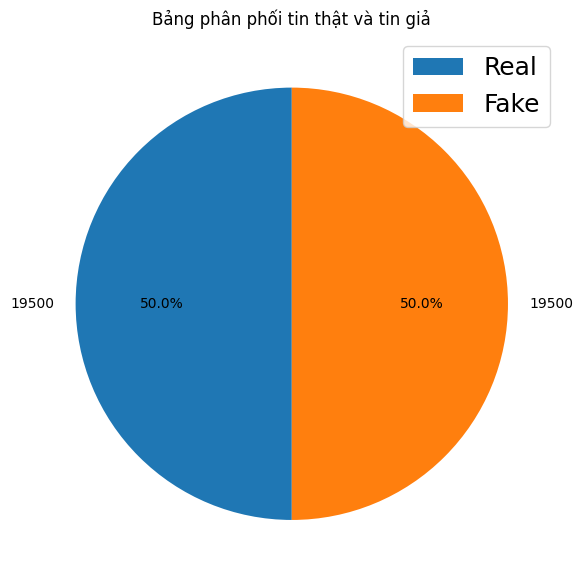

In [95]:
# data quantity chart
def quantity_chart():
    counts_df1 = data_df['label'].value_counts()

    plt.figure(figsize=(6, 6))

    plt.pie(counts_df1, labels=counts_df1, autopct='%1.1f%%', startangle=90)
    plt.title('Bảng phân phối tin thật và tin giả')

    labels = ['Real' if label == 0 else 'Fake' for label in counts_df1.index]
    plt.legend(labels=labels, loc="best", fontsize=18)  # Tăng kích thước nhãn trong chú thích
    plt.tight_layout()
    plt.show()
quantity_chart()

#### Các thông tin thống kê

##### Chiều dài trung bình mỗi record là bao nhiêu?

In [96]:
len_sum=0
for i in data_df['text']:
    len_sum+=len(i)
len_avg=len_sum/data_df['text'].count()
len_avg

2434.940871794872

##### Record dài nhất là bao nhiêu?

In [97]:
max_len=0
for i in data_df['text']:
    if len(i)>max_len:
        max_len=len(i)
max_len

49071

##### Record ngắn nhất là bao nhiêu?

In [98]:
min_len=len(data_df['text'][0])
for i in data_df['text']:
    if len(i)<min_len:
        min_len=len(i)
min_len

107

### Tiền xử lí văn bản

#### Loại bỏ các đường link và các dấu câu, lowercase

In [99]:
import nltk
from nltk.corpus import stopwords

# Tải stopwords từ NLTK nếu chưa tải
# nltk.download('stopwords')

# Sử dụng danh sách từ dừng (stopwords) của tiếng Anh từ NLTK
stopword_list = list(stopwords.words('english'))
stopwords = [word for word in stopword_list if word.strip() != '']


In [100]:
import string
def wordopt(text):
    text=re.sub("Reuters"," ",text)

    update_text =""

    text = text.lower()

    text=re.sub("reuters"," ",text)
    
    #simplifying text
    text=re.sub(r"i'm","i am",text)
    text=re.sub(r"he's","he is",text)
    text=re.sub(r"she's","she is",text)
    text=re.sub(r"that's","that is",text)
    text=re.sub(r"what's","what is",text)
    text=re.sub(r"where's","where is",text)
    text=re.sub(r"\'ll"," will",text)
    text=re.sub(r"\'ve"," have",text)
    text=re.sub(r"\'re"," are",text)
    text=re.sub(r"\'d"," would",text)
    text=re.sub(r"won't","will not",text)
    text=re.sub(r"can't","cannot",text)


    text=re.sub(r"[-()\"#!@$%^&*{}?.,:]"," ",text)
    text=re.sub(r"\s+"," ",text)

    text = re.sub('\[.*?\]', '', text)
    text = re.sub("\\W", " ", text)
    text = re.sub('https?://\S+|www\.\S+', '', text)
    text = re.sub('<.*?>+', '', text)
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub('\n', '', text)
    text = re.sub('\w*\d\w*', '', text)

    for word in text.split():
        if word not in stopwords:
            update_text += word+" "
    
    return update_text.strip()


In [101]:
data_df['article'] = ' |title| '+ data_df["title"] +' |text| '+  data_df["text"] 

In [102]:
data_df.head(1)

title  \
0  As U.S. budget fight looms Republicans flip their fiscal script   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                

In [103]:
data_df['Compound_Content_SW'] = data_df['article'].apply(wordopt)

In [104]:
data_df.head(1)

title  \
0  As U.S. budget fight looms Republicans flip their fiscal script   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                

# Vector hóa

#### Tokenizer

In [105]:
def tokenize(sentence):
    return word_tokenize(sentence, format = 'word')

### Mô hình hóa

- Chuyển đoạn văn tiếng Việt về vector
- với các tham số là danh sách stopwords tiếng Việt
- và tokenizer tách từ tiếng Việt

In [106]:
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

Chia tập dữ liệu thành 2 tập

- Tập train: 75%
- Tập test: 25%


In [107]:
X = data_df["Compound_Content_SW"]
y = data_df["label"]
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.25,
                                                   random_state=30)

In [108]:
from sklearn.ensemble import RandomForestClassifier

# Vector

In [109]:
model_vector_CV = os.path.join("../../Vector/English/CV", "English_vectorizer_CV.joblib")
model_RFC_CV = os.path.join("../../Vector/English/CV", "English_RFC_model_CV.joblib")


In [110]:
model_vector_TF = os.path.join("../../Vector/English/TF", "English_vectorizer_TF.joblib")
model_RFC_TF = os.path.join("../../Vector/English/TF", "English_RFC_model_TF.joblib")

In [111]:
model_vector_W2V = os.path.join("../../Vector/English/W2V", "English_vectorizer_W2V.joblib")
model_RFC_W2V = os.path.join("../../Vector/English/W2V", "English_RFC_model_W2V.joblib")

In [112]:
model_vector_D2V = os.path.join("../../Vector/English/D2V", "English_vectorizer_D2V.joblib")
model_RFC_D2V = os.path.join("../../Vector/English/D2V", "English_RFC_model_D2V.joblib")

In [113]:
from sklearn.feature_extraction.text import CountVectorizer

from sklearn.feature_extraction.text import TfidfVectorizer

from gensim.models import Word2Vec
import numpy as np

from gensim.models import Doc2Vec
from gensim.models.doc2vec import TaggedDocument

## CountVectorizer

In [114]:
vectorizerCV = CountVectorizer(
    stop_words = stopwords,
    tokenizer = tokenize,
)

In [115]:
Xv_trainCV = vectorizerCV.fit_transform(X_train)
Xv_testCV = vectorizerCV.transform(X_test)

## TfidfVectorizer

In [116]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [117]:
vectorizerTF = TfidfVectorizer(max_features=50000, stop_words=stopwords, min_df=0.002, max_df=0.5, 
                                   use_idf=True, ngram_range=(1,3))

In [118]:
Xv_trainTF = vectorizerTF.fit_transform(X_train)
Xv_testTF = vectorizerTF.transform(X_test)

## Word2Vec

In [119]:
def makeWords(sentences):
    wordList = []
    for sentence in sentences:
        words = sentence.split(' ')
        wordList.append(words)
    return wordList

words_train_W2V = makeWords(X_train)
words_test_W2V = makeWords(X_test)

In [120]:
# Train the Word2Vec model on the tokenized training sentences
vectorizerW2V = Word2Vec(
    sentences=words_train_W2V,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    sg=0,
    epochs=10
)

In [121]:
# Function to calculate the average Word2Vec vector for each sentence
def sentence_vector(sentence, model):
    # Get vectors for words in the sentence if they exist in the vocabulary
    vectors = [model.wv[word] for word in sentence if word in model.wv]
    if len(vectors) > 0:
        # Calculate the mean of the word vectors for the sentence
        return np.mean(vectors, axis=0)
    else:
        # Return a zero vector if no words in the sentence are in the vocabulary
        return np.zeros(model.vector_size)

In [122]:
Xv_trainW2V = np.array([sentence_vector(sentence, vectorizerW2V) for sentence in words_train_W2V])
Xv_testW2V = np.array([sentence_vector(sentence, vectorizerW2V) for sentence in words_test_W2V])

## Doc2Vec

In [123]:
documents = [TaggedDocument(doc.split(), [i]) for i, doc in enumerate(X_train)]

In [124]:
vectorizerD2V = Doc2Vec(
    documents=documents,  # Truyền documents trực tiếp
    vector_size=100,      # Kích thước vector
    window=5,             # Kích thước cửa sổ ngữ cảnh
    min_count=1,          # Bỏ qua từ xuất hiện ít hơn min_count
    workers=4,            # Số luồng để huấn luyện
    epochs=20             # Số lần lặp để huấn luyện
)

In [125]:
Xv_trainD2V = [vectorizerD2V.infer_vector(doc.split()) for doc in X_train]
Xv_testD2V = [vectorizerD2V.infer_vector(doc.split()) for doc in X_test]

## Save model

In [126]:
# joblib.dump(vectorizerCV, model_vector_CV)
# joblib.dump(vectorizerTF, model_vector_TF)
# joblib.dump(vectorizerW2V,model_vector_W2V)
# joblib.dump(vectorizerD2V, model_vector_D2V)

# Train RandomForestClassifier

In [127]:
rfc_cv = RandomForestClassifier(random_state=42)
rfc_tf = RandomForestClassifier(random_state=42)
rfc_w2v = RandomForestClassifier(random_state=42)
rfc_d2v = RandomForestClassifier(random_state=42)

## CountVectorizer

In [128]:
rfc_cv.fit(Xv_trainCV,y_train)
pred_rfc_cv = rfc_cv.predict(Xv_testCV)

## TfidfVectorizer

In [129]:
rfc_tf.fit(Xv_trainTF,y_train)
pred_rfc_tf = rfc_tf.predict(Xv_testTF)

## Word2Vec

In [130]:
rfc_w2v.fit(Xv_trainW2V, y_train)
pred_rfc_w2v = rfc_w2v.predict(Xv_testW2V)

## Doc2Vec

In [131]:
rfc_d2v.fit(Xv_trainD2V, y_train)
pred_rfc_d2v = rfc_d2v.predict(Xv_testD2V)

# evaluate_model

In [132]:
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, confusion_matrix

In [133]:
def evaluate_model(y_true, y_pred, name_model):
    """
    Tính toán các chỉ số đánh giá mô hình.
    Args:
        y_true (array-like): Nhãn thực tế.
        y_pred (array-like): Nhãn dự đoán.

    Returns:
        dict: Các chỉ số bao gồm Precision, Recall, Accuracy, F1-score, FPR, FNR.
    """
    # Precision (PPV)
    precision = precision_score(y_true, y_pred, pos_label=1)
    
    # Recall (TPR)
    recall = recall_score(y_true, y_pred, pos_label=1)
    
    # Accuracy (ACC)
    accuracy = accuracy_score(y_true, y_pred)
    
    # F1-Score
    f1 = f1_score(y_true, y_pred)
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # False Positive Rate (FPR): FP / (FP + TN)
    fpr = cm[0][1] / (cm[0][1] + cm[0][0]) if (cm[0][1] + cm[0][0]) > 0 else 0.0
    
    # False Negative Rate (FNR): FN / (FN + TP)
    fnr = cm[1][0] / (cm[1][0] + cm[1][1]) if (cm[1][0] + cm[1][1]) > 0 else 0.0
    
    # Kết quả
    metrics = {
        "Precision (PPV)": precision,
        "Recall (TPR)": recall,
        "Accuracy (ACC)": accuracy,
        "F1-Score": f1,
        "False Positive Rate (FPR)": fpr,
        "False Negative Rate (FNR)": fnr,
    }
    metrics_df = pd.DataFrame(metrics.items(), columns=["Method", "Value"])
    path_evaluate = os.path.join("../../Evaluate/English", f"English_Evaluate_{name_model}.csv")
    metrics_df.to_csv(path_evaluate, index=False)

## Predict model

In [134]:
from sklearn.metrics import confusion_matrix  
import seaborn as sns

In [135]:
accuracy = accuracy_score(y_test, pred_rfc_cv) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_rfc_cv))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_rfc_cv,name_model="rfc_cv")

0.9832820512820513
-------------------

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      4879
           1       0.98      0.98      0.98      4871

    accuracy                           0.98      9750
   macro avg       0.98      0.98      0.98      9750
weighted avg       0.98      0.98      0.98      9750

-------------------



[[4799   80]
 [  83 4788]]


<Axes: >

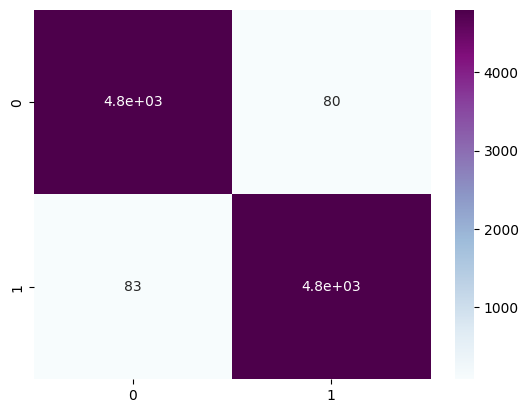

In [136]:
cm = confusion_matrix(y_test,pred_rfc_cv)
print(cm)
sns.heatmap(cm,cmap="BuPu",annot=True)

In [137]:
accuracy = accuracy_score(y_test, pred_rfc_tf) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_rfc_tf))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_rfc_tf,name_model="rfc_tf")

0.9894358974358974
-------------------

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4879
           1       0.99      0.99      0.99      4871

    accuracy                           0.99      9750
   macro avg       0.99      0.99      0.99      9750
weighted avg       0.99      0.99      0.99      9750

-------------------



[[4832   47]
 [  56 4815]]


<Axes: >

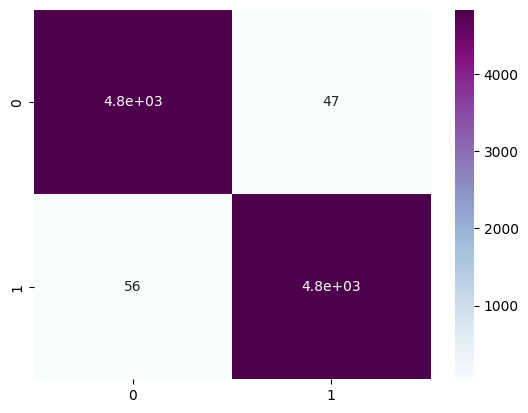

In [138]:
cm = confusion_matrix(y_test,pred_rfc_tf)
print(cm)
sns.heatmap(cm,cmap="BuPu",annot=True)

In [139]:
accuracy = accuracy_score(y_test, pred_rfc_w2v) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_rfc_w2v))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_rfc_w2v,name_model="rfc_w2v")


0.9627692307692308
-------------------

              precision    recall  f1-score   support

           0       0.96      0.96      0.96      4879
           1       0.96      0.96      0.96      4871

    accuracy                           0.96      9750
   macro avg       0.96      0.96      0.96      9750
weighted avg       0.96      0.96      0.96      9750

-------------------



[[4695  184]
 [ 179 4692]]


<Axes: >

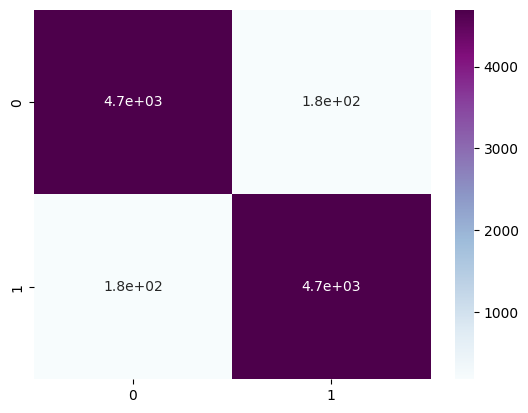

In [140]:
cm = confusion_matrix(y_test,pred_rfc_w2v)
print(cm)
sns.heatmap(cm,cmap="BuPu",annot=True)

In [141]:
accuracy = accuracy_score(y_test, pred_rfc_d2v) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_rfc_d2v))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_rfc_d2v,name_model="rfc_d2v")

0.9428717948717948
-------------------

              precision    recall  f1-score   support

           0       0.95      0.93      0.94      4879
           1       0.93      0.95      0.94      4871

    accuracy                           0.94      9750
   macro avg       0.94      0.94      0.94      9750
weighted avg       0.94      0.94      0.94      9750

-------------------



[[4550  329]
 [ 228 4643]]


<Axes: >

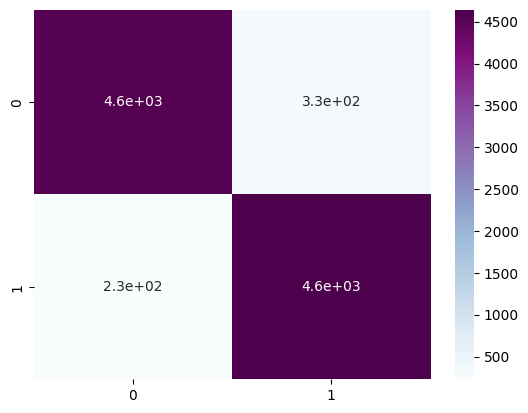

In [142]:
cm = confusion_matrix(y_test,pred_rfc_d2v)
print(cm)
sns.heatmap(cm,cmap="BuPu",annot=True)

# Save model RFC

In [143]:
# joblib.dump(rfc_cv, model_RFC_CV)
# joblib.dump(rfc_tf, model_RFC_TF)
# joblib.dump(vectorizerW2V,model_vector_W2V)
# joblib.dump(rfc_d2v, model_RFC_D2V)

# Vector TF-IDF

In [144]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB


In [145]:
nb_model = MultinomialNB()
nb_model.fit(Xv_trainTF, y_train)
y_pred_nb = nb_model.predict(Xv_testTF)
print("Naive Bayes Results")
print(classification_report(y_test, y_pred_nb))


Naive Bayes Results
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      4879
           1       0.96      0.96      0.96      4871

    accuracy                           0.96      9750
   macro avg       0.96      0.96      0.96      9750
weighted avg       0.96      0.96      0.96      9750



[[4664  215]
 [ 211 4660]]


<Axes: >

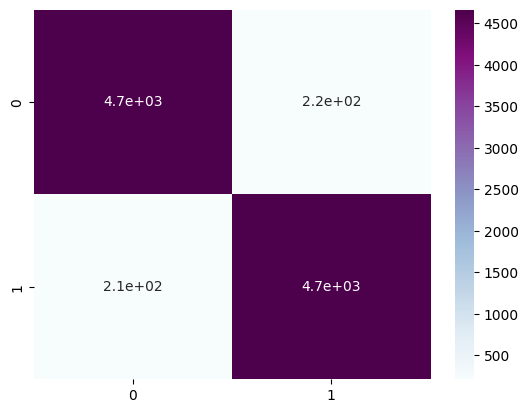

In [146]:
cm = confusion_matrix(y_test,y_pred_nb)
print(cm)
sns.heatmap(cm,cmap="BuPu",annot=True)

In [147]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(Xv_trainTF, y_train)
y_pred_dt = dt_model.predict(Xv_testTF)
print("Decision Tree Results")
print(classification_report(y_test, y_pred_dt))


Decision Tree Results
              precision    recall  f1-score   support

           0       0.97      0.95      0.96      4879
           1       0.95      0.97      0.96      4871

    accuracy                           0.96      9750
   macro avg       0.96      0.96      0.96      9750
weighted avg       0.96      0.96      0.96      9750



[[4620  259]
 [ 134 4737]]


<Axes: >

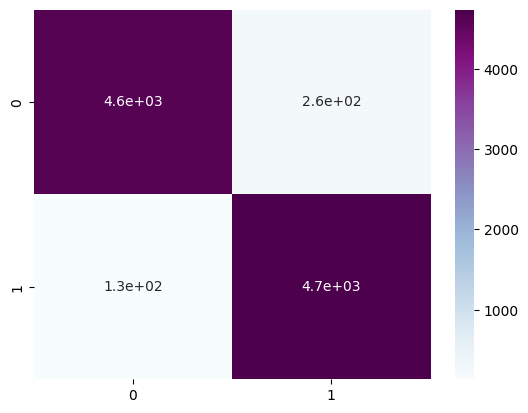

In [148]:
cm = confusion_matrix(y_test,y_pred_dt)
print(cm)
sns.heatmap(cm,cmap="BuPu",annot=True)

In [149]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(Xv_trainTF, y_train)
y_pred_rf = rf_model.predict(Xv_testTF)
print("Random Forest Results")
print(classification_report(y_test, y_pred_rf))


Random Forest Results
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4879
           1       0.99      0.99      0.99      4871

    accuracy                           0.99      9750
   macro avg       0.99      0.99      0.99      9750
weighted avg       0.99      0.99      0.99      9750



[[4832   47]
 [  56 4815]]


<Axes: >

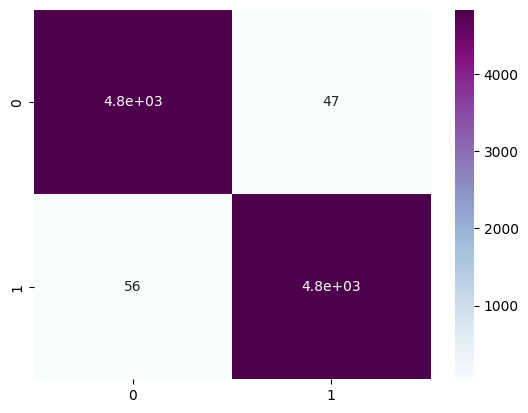

In [150]:
cm = confusion_matrix(y_test,y_pred_rf)
print(cm)
sns.heatmap(cm,cmap="BuPu",annot=True)

In [151]:
svm_model = LinearSVC(random_state=42)
svm_model.fit(Xv_trainTF, y_train)
y_pred_svm = svm_model.predict(Xv_testTF)
print("SVM Results")
print(classification_report(y_test, y_pred_svm))


SVM Results
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      4879
           1       1.00      0.99      0.99      4871

    accuracy                           0.99      9750
   macro avg       0.99      0.99      0.99      9750
weighted avg       0.99      0.99      0.99      9750



[[4858   21]
 [  43 4828]]


<Axes: >

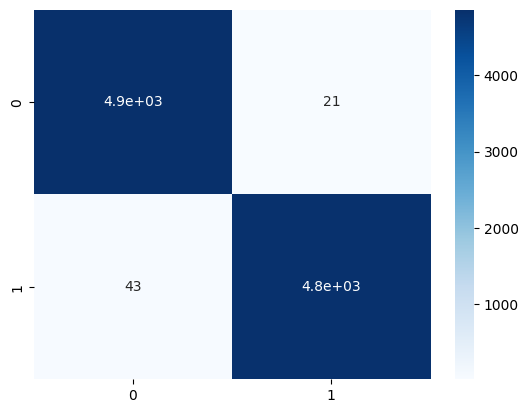

In [152]:
cm= confusion_matrix(y_test,y_pred_svm)  
print(cm)
import seaborn as sns
sns.heatmap(cm,cmap="Blues",annot=True)